<div style="text-align:center">
<h1>Section 9: Analysing Raster Data (Part II)</h1>
<h2>5SSG2060 Principles of Spatial Data Science</h2>
</div>

## Contents
0. <a href=#section0>Intro and Setup</a>
1. <a href=#section1>Reading Raster Data</a>
2. <a href=#section2>Analysing Zonal Change</a>
3. <a href=#section3>Landscape Pattern Analysis</a>
4. <a href=#section4>Analysing Pixel-by-Pixel Change</a>

<a name="section0"></a>
## 0. Intro and Setup

This notebook continues our analyses of Wales' land use/cover from last week. You will need the raster files you output last week. 

By the end of this practical you should:
- have continued to develop your skills working with raster data
- understand how to use Zonal Analysis to summarise raster data in sub-regions defined by polygon data (zones)
- understand how landscape metrics can be used to examine changes in landscape pattern over time at different levels (based on patches) 
- know what a contingency table is and how to use one to examine differences (and change) in raster data (for individual pixels)  


Load all required packages for the notebook:

In [2]:
#handle warnings
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

import rasterio as rio
from rasterio.plot import show

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm

import pandas as pd
import geopandas as gpd
import numpy as np

from rasterstats import zonal_stats  #for zonal analysis
import pylandstats as pls      #for landscape metrics
from sklearn import metrics    #for confusion matrix

<a name="section1"></a>
## 1. Reading Raster Data

Last week, we used the `open` [function](https://rasterio.readthedocs.io/en/latest/api/rasterio.html#rasterio.open) from `Rasterio` directly to create a `DatasetReader` object. Then used the `read` method to receive a [numpy n-dimensional array](https://numpy.org/doc/stable/reference/arrays.ndarray.html) object, known as `ndarray`:

In [3]:
# read in the lcm2015_wales6.tif data generated from last week
lcm2015_wales6_dr = rio.open("data/lcm2015_wales6.tif")
#2d numpy ndarray
lcm2015_wales6= lcm2015_wales6_dr.read(1)

Note the code above creates a 2D numpy array

In [4]:
print(lcm2015_wales6.shape)

(231, 210)


#### TASK   

Similarly, please read in the ***lcm1990_wales6.tif*** data from last week, creating and object named *lcm1990_wales6* that contains 1990 data for Wales as a 2D `numpy array`.

In [5]:
# read in the lcm1990_wales6.tif data
lcm1990_wales6_dr = rio.open("data/lcm1990_wales6.tif")   
#2d numpy ndarray
lcm1990_wales6 = lcm1990_wales6_dr.read(1)  

Last week we also created some data structures when plotting - these will be useful again this week:

In [6]:
#define legend based on provided information
#legend mapping land cover values to class names
legend_dict = {
    0: ['No Data', 'white'],
    1: ['Woodland', 'darkgreen'],
    2: ['Cropland', 'lightyellow'],
    3: ['Grassland', 'lightgreen'],
    4: ['Water', 'blue'],
    5: ['Built-up', 'black'],
    6: ['Other', 'grey'],
}

#create colormap using colours specified in the legend dict
lccolors = [legend_dict[key][1] for key in sorted(legend_dict.keys())]
lcmap = ListedColormap(lccolors)

#create list of ids (in the raster) from the legend keys, adding an upper bound greater than current largest
bounds = list(legend_dict.keys())
bounds.append(bounds[-1] + 1)

#create a BoundaryNorm object to scale the colormap to the legend values, e.g. https://stackoverflow.com/a/14779462
bnorm = BoundaryNorm(bounds, lcmap.N)

#create colour boxes for the map legend from the legend_dict 
colourboxes = [plt.Rectangle(xy=(0, 0),width=1,height=1, 
                         facecolor=legend_dict[key][1],edgecolor='black') for key in sorted(legend_dict.keys())]

#create labels from the legend_dict
lclabels = [f"{legend_dict[key][0]}" for key in sorted(legend_dict.keys())]

#dict of ids and labels only
idlabs = dict(zip(legend_dict.keys(), lclabels))

<a name="section2"></a>
## 2. Analysing Zonal Change

This section assumes you have worked through the Zonal Statistics notebook available on KEATS.

The analysis of our data last week was aggregated for our entire area (Wales). Below we'll analyse data on a pixel-by-pixel basis. But sometimes we want to work at a level in between, using zones that belong to some kind of vector geography. This is where raster _zonal statistics_ come in:

> Zonal Statistics uses groupings to calculate statistics for specified zones. [source](https://gisgeography.com/zonal-statistics/)

The statistics are summary statistics (e.g. mean, median, standard deviation) of all the pixels that fall in each zone. The zones might be watersheds, biomes or ecoregions (physically) or states, countries, counties or census districts (socio-econmically). 

Zonal statistics is how the air quality data was created for the 2021 census datset used in Foundations of SDS - the original data were raster then vector data for LSOAs, MSOAs and Boroughs was used to summarise to the relevant census unit.   

In her talk, Clare Rowland presented zonal statistics of land cover change for UK counties as choropleth maps (remember them from Foundations of SDS?). We'll make similar choropleth maps, but also think about how we could improve on what was presented. 

### Reading polygon data

To create county-level summaries of change we need polygons to define these zones. These polygons will need to have the same coordinate reference system as the raster data so that they align spatially. 

We'll read the data using GeoPandas:

In [7]:
GB = gpd.read_file('data/CTYUA_(Dec_2019)_Ultra_Generalised_Clipped_Boundaries_in_the_UK.geojson').set_index('ctyua19nm')
GB.head()

,OBJECTID,ctyua19cd,ctyua19nmw,bng_e,bng_n,long,lat,GlobalID,SHAPE_Length,SHAPE_Area,geometry
ctyua19nm,,,,,,,,,,,
Hartlepool,1,E06000001,,447160,531474,-1.27018,54.676140,{70A72826-C9A1-4826-9B47-CCEBF29EEF07},0.654035,0.013493,"MULTIPOLYGON (((-1.24099 54.72319, -1.17617 54..."
Middlesbrough,2,E06000002,,451141,516887,-1.21099,54.544670,{77377060-55E8-41E2-8FA0-F0E450F22B5A},0.452613,0.007349,"MULTIPOLYGON (((-1.2009 54.57764, -1.19056 54...."
Redcar and Cleveland,3,E06000003,,464361,519597,-1.00608,54.567520,{922557F5-4E33-4FC1-AFE6-98D2906DC9CE},1.118123,0.034547,"MULTIPOLYGON (((-1.19752 54.58211, -1.16019 54..."
Stockton-on-Tees,4,E06000004,,444940,518183,-1.30664,54.556911,{148A3F71-5D57-455E-8851-05C075F8B306},1.064817,0.028787,"MULTIPOLYGON (((-1.19752 54.58211, -1.2009 54...."
Darlington,5,E06000005,,428029,515648,-1.56835,54.535339,{87021DC3-C6DA-4CEC-BD9F-6EA5AC4FF744},1.129501,0.027620,"MULTIPOLYGON (((-1.69693 54.53601, -1.70527 54..."


In these data, each row (polygon) is a county (or unitary authority) for Great Britain. 

Look at the geometry column - what coordinate reference system (CRS) do you think the data are using? It is latitude and longitude for WGS84, and a peculiarity of the `geojson` data format (which the data were stored and read in as):
> The coordinate reference system for all GeoJSON coordinates is a geographic coordinate reference system, using the [World Geodetic System 1984 (WGS 84) datum](https://epsg.io/4326), with longitude and latitude units of decimal degrees. [[source]](https://datatracker.ietf.org/doc/html/rfc7946#page-12)

For data you read in from a `geojson` file, you should always set the CRS of the data yourself; we don't need to re-project our data, rather we just update the `crs` attribute of the data:  

In [8]:
GB  = GB.to_crs({'init': 'epsg:27700'}) 

As [the GeoPandas docs show](https://geopandas.org/docs/reference/api/geopandas.GeoDataFrame.crs.html#geopandas.GeoDataFrame.crs), we can use a code from an 'authority' on CRS, like [EPSG](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset), to set the `crs` attribute of our data. The EPSG code of OSGB 1936 is `27700` (hence that value used in the code above). You can find ESPG codes for different CRS by [searching epsg.io](https://epsg.io).

Good. So now we should be able to plot the data:

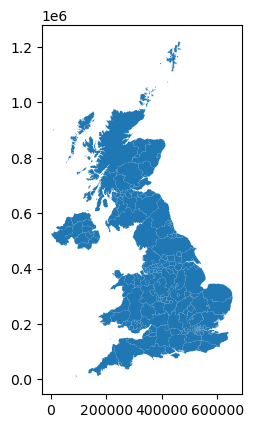

In [9]:
GB.plot()
plt.show()

In [10]:
GB.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

That looks right! If we hadn't corrected the `crs` attribute, we would have received an error when trying to do that plot (try it for yourself by re-reading the data and plotting without updating the `crs`). 

So that's polygons for the whole of GB. How do we get polygons just for Wales? 

Note that the first letter of the `ctyua19cd` variable (which is the 'county and unitary authority code for 2019') indicates which country (England, Scotland, Wales) the county is located in. We can use that information to filter our GeoDataFrame (with help from the `.str.startswith` method). 

In [11]:
wales = GB[GB['ctyua19cd'].str.startswith("W")]
wales

,OBJECTID,ctyua19cd,ctyua19nmw,bng_e,bng_n,long,lat,GlobalID,SHAPE_Length,SHAPE_Area,geometry
ctyua19nm,,,,,,,,,,,
Isle of Anglesey,195,W06000001,Ynys Môn,245212,378343,-4.32306,53.279419,{8BF0D9A8-D8E2-4350-9B1B-66F0BA193ED0},2.553618,0.095691,"MULTIPOLYGON (((243981.803 363857.256, 244275...."
Gwynedd,196,W06000002,Gwynedd,280555,334966,-3.77715,52.898830,{E5D7C3AC-8CCC-4243-AC9B-D95A7364DEEC},5.166330,0.341199,"MULTIPOLYGON (((262450.414 338569.41, 260480.2..."
Conwy,197,W06000003,Conwy,283293,362563,-3.74646,53.147388,{2DCC7A8A-4105-44B4-92B7-3A2C05F06699},2.389394,0.152695,"MULTIPOLYGON (((299744.924 380361.549, 299763...."
Denbighshire,198,W06000004,Sir Ddinbych,309843,355416,-3.34761,53.088329,{4F3A7E79-5AB8-4456-99EC-6784EDE536C6},2.303349,0.112050,"MULTIPOLYGON (((308927.407 382801.808, 307622...."
Flintshire,199,W06000005,Sir y Fflint,321134,369280,-3.18248,53.214710,{5BC14314-3480-4F68-B101-2DB025A30E6A},1.695096,0.058726,"MULTIPOLYGON (((312716.466 383625.725, 313635...."
Wrexham,200,W06000006,Wrecsam,333523,345387,-2.99203,53.001671,{0C017621-86B8-4913-A04F-3DF64CB2923D},1.949306,0.067871,"MULTIPOLYGON (((324414.214 353387.707, 328347...."
Ceredigion,201,W06000008,Ceredigion,267127,268437,-3.94993,52.297951,{CE309A5B-F957-4F90-BD10-E99DD40C08C0},3.112659,0.235013,"MULTIPOLYGON (((270876.812 297590.994, 274047...."
Pembrokeshire,202,W06000009,Sir Benfro,199821,221392,-4.90818,51.855129,{A5C6A775-BBA0-4CED-BE57-DF7364B5337F},4.229063,0.213228,"MULTIPOLYGON (((216211.911 244671.907, 217217...."
Carmarthenshire,203,W06000010,Sir Gaerfyrddin,247954,224133,-4.21110,51.894951,{9C782115-56B5-46D8-AE9A-3F05021378C4},3.846338,0.309487,"MULTIPOLYGON (((279749.21 249226.602, 282307.1..."


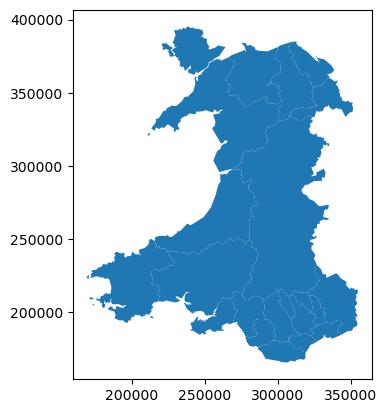

In [12]:
wales.plot()
plt.show()

Now let's try to plot these polygons on top of our raster data - this is where all the CRS stuff is really important!

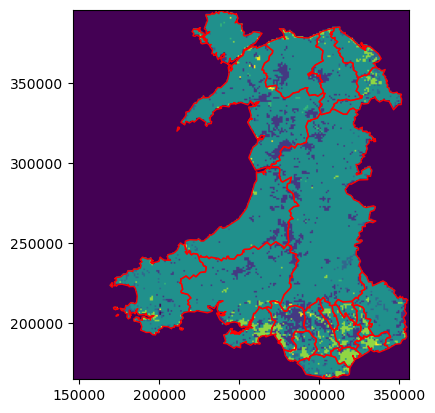

In [13]:
fig,ax=plt.subplots()
show((lcm2015_wales6_dr,1), cmap='viridis',ax=ax)  #rasterio show, reading the first layer from the DatasetReader object
wales.plot(ax=ax, facecolor='None', edgecolor='red', linewidth=1)
plt.show()

Hooray! The Wales polygons align spatially match with the GB raster.

Note, how the code to produce ths plot uses the `rasterio show` function, ensuring that the CRS data for the raster is used when plotting. 

### Zonal Summary

To do our zonal summary, we can use the `zonal_stats` [function](https://pythonhosted.org/rasterstats/manual.html#zonal-statistics) from the `rasterstats` [package](https://pythonhosted.org/rasterstats/). 

To the `zonal_stats` function we will pass:
- the polygons that specify our zones (as a `GeoDataFrame`)
- the raster data (as `ndarray`) to be summarised
- the geospatial information for the raster data (from the `transform` key of the `meta` attribute (`dict`) of the `rio.DatasetReader` object)
- we specify `categorical=True` so that counts are returned (rather than other inappropriate summary stats for categorical data, like the mean)

So, for our 2015 data:

In [14]:
#from rasterstats import zonal_stats
#calculate raster stats
zs_wales15_6 = zonal_stats(wales, lcm2015_wales6,
                           affine=lcm2015_wales6_dr.meta['transform'],
                           categorical=True)
zs_wales15_6  

[{0: 2, 1: 15, 2: 4, 3: 668, 4: 4, 5: 12, 6: 4},
 {0: 4, 1: 354, 2: 32, 3: 2113, 4: 17, 5: 17, 6: 17},
 {1: 127, 2: 3, 3: 975, 4: 5, 5: 32, 6: 1},
 {1: 81, 2: 14, 3: 722, 4: 1, 5: 16},
 {0: 4, 1: 10, 2: 30, 3: 348, 5: 43, 6: 1},
 {1: 15, 2: 44, 3: 405, 5: 39},
 {0: 1, 1: 183, 2: 10, 3: 1588, 5: 9, 6: 2},
 {0: 8, 1: 34, 2: 106, 3: 1435, 4: 1, 5: 39, 6: 12},
 {1: 182, 2: 4, 3: 2135, 5: 45, 6: 2},
 {1: 32, 2: 8, 3: 265, 4: 1, 5: 73},
 {0: 1, 1: 198, 2: 1, 3: 172, 4: 2, 5: 64, 6: 7},
 {1: 34, 2: 16, 3: 152, 5: 45, 6: 3},
 {1: 11, 2: 50, 3: 233, 4: 1, 5: 32, 6: 1},
 {1: 7, 2: 4, 3: 44, 4: 2, 5: 85},
 {1: 118, 2: 6, 3: 239, 5: 59, 6: 2},
 {1: 52, 2: 1, 3: 173, 5: 53},
 {1: 9, 3: 83, 5: 16},
 {1: 14, 3: 80, 4: 1, 5: 29},
 {1: 86, 2: 42, 3: 712, 4: 1, 5: 17},
 {1: 11, 2: 18, 3: 110, 4: 2, 5: 48, 6: 3},
 {1: 452, 2: 75, 3: 4639, 4: 12, 5: 14, 6: 2},
 {1: 19, 3: 74, 5: 17, 6: 1}]

What is all this output? Well, it's a `dict` for each of our polygons with the pixel count (the `value`s) for each of the land cover IDs (the `key`s) found in the raster. We get counts and not some other summary statistic because our data are categorical). 

Note, that it's not explicitly made clear in the `rasterstats` [docs](https://pythonhosted.org/rasterstats), but we will assume that output is in the same order as the input polygons (as mentioned [here](https://github.com/perrygeo/python-rasterstats/issues/137)).

To make a choropleth map it's useful to have our data in a GeoPandas `GeoDataFrame`. It's relatively easy to convert our raster zonal stats `dict` into a Pandas `DataFrame`:

In [15]:
#convert the zonal stats dict to a dataframe
zs_wales15_6_pd = pd.DataFrame(zs_wales15_6)
zs_wales15_6_pd.head()

,0,1,2,3,4,5,6
0,2.0,15,4.0,668,4.0,12,4.0
1,4.0,354,32.0,2113,17.0,17,17.0
2,NaN,127,3.0,975,5.0,32,1.0
3,NaN,81,14.0,722,1.0,16,NaN
4,4.0,10,30.0,348,NaN,43,1.0


But now we need to `join` our data to the `wales` `GeoDataFrame` so that we have the geometry information for plotting. 

In [16]:
#set the index to be the same as `wales` for later joining
zs_wales15_6_pd.set_index(wales.index,inplace=True)
#use the idlabs dict we created above
zs_wales15_6_pd.rename(columns=idlabs,inplace=True) 
#set column names with `15` suffix to distinguish from other years' data
zs_wales15_6_pd = zs_wales15_6_pd.add_suffix('15')
#join to wales `GeoDataFrame` by creating a new object 
wales_gpd = pd.merge(wales, zs_wales15_6_pd, how='left', left_index=True, right_index=True)
wales_gpd.head()

,OBJECTID,ctyua19cd,ctyua19nmw,bng_e,bng_n,long,lat,GlobalID,SHAPE_Length,SHAPE_Area,geometry,No Data15,Woodland15,Cropland15,Grassland15,Water15,Built-up15,Other15
ctyua19nm,,,,,,,,,,,,,,,,,,
Isle of Anglesey,195,W06000001,Ynys Môn,245212,378343,-4.32306,53.279419,{8BF0D9A8-D8E2-4350-9B1B-66F0BA193ED0},2.553618,0.095691,"MULTIPOLYGON (((243981.803 363857.256, 244275....",2.0,15,4.0,668,4.0,12,4.0
Gwynedd,196,W06000002,Gwynedd,280555,334966,-3.77715,52.898830,{E5D7C3AC-8CCC-4243-AC9B-D95A7364DEEC},5.166330,0.341199,"MULTIPOLYGON (((262450.414 338569.41, 260480.2...",4.0,354,32.0,2113,17.0,17,17.0
Conwy,197,W06000003,Conwy,283293,362563,-3.74646,53.147388,{2DCC7A8A-4105-44B4-92B7-3A2C05F06699},2.389394,0.152695,"MULTIPOLYGON (((299744.924 380361.549, 299763....",NaN,127,3.0,975,5.0,32,1.0
Denbighshire,198,W06000004,Sir Ddinbych,309843,355416,-3.34761,53.088329,{4F3A7E79-5AB8-4456-99EC-6784EDE536C6},2.303349,0.112050,"MULTIPOLYGON (((308927.407 382801.808, 307622....",NaN,81,14.0,722,1.0,16,NaN
Flintshire,199,W06000005,Sir y Fflint,321134,369280,-3.18248,53.214710,{5BC14314-3480-4F68-B101-2DB025A30E6A},1.695096,0.058726,"MULTIPOLYGON (((312716.466 383625.725, 313635....",4.0,10,30.0,348,NaN,43,1.0


And now we can make a plot of, for example, total **Grassland in 2015** by county: 

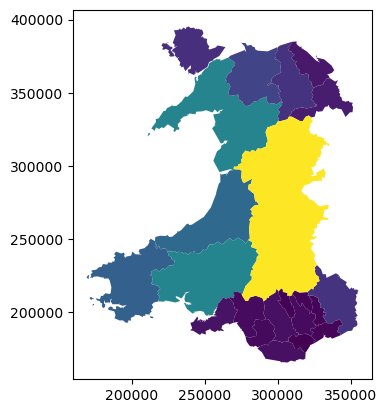

In [17]:
wales_gpd.plot('Grassland15')
plt.show()

Cool! But let's improve that plot by specifying the classification and providing a legend:

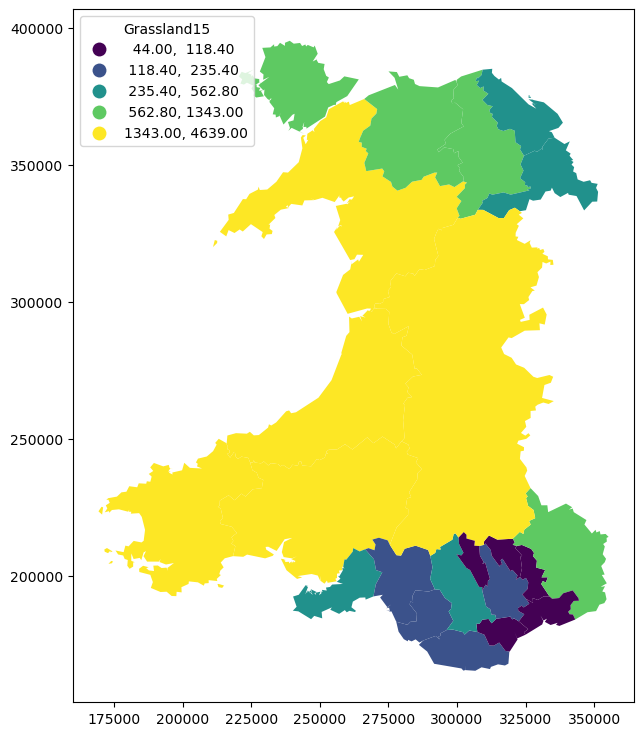

In [18]:
col = 'Grassland15'

fig, ax = plt.subplots(1, figsize=(9, 9))

wales_gpd.plot(column=col, cmap='viridis', 
        scheme='quantiles', k=5, 
        linewidth=0., 
        legend=True, legend_kwds={"title":col,"loc": 2},
        ax=ax
       )

plt.show()

This is a vector map summarising raster data. Check you understand the steps we have taken to create this map:
1. use `zonal_stats` to summarise raster cells by polygon
2. convert output from `zonal_stats` to a Pandas `DataFrame`
3. join the zonal summaries `DataFrame` to an existing `GeoDataFrame`
4. plot the summary for one land cover type from the `GeoDataFrame` 

This figure still isn't perfect (think about whether we have a _spatially intensive_ or a _spatially extensive_ variable... ), but it will do for now because really what we want to plot is land cover change by county (as in Clare's talk). 

#### TASK

Similarly, we can calculate zonal stats for 1990 and join them to our `GeoDataFrame`:

In [19]:
#calculate zonal stats
zs_wales90_6 = zonal_stats(wales_gpd, lcm1990_wales6,
                           affine=lcm1990_wales6_dr.meta['transform'],
                           categorical=True)

#convert the zonal stats dict to a dataframe
zs_wales90_6_pd = pd.DataFrame(zs_wales90_6)
#set the index to be the same as `wales` for later joining
zs_wales90_6_pd.set_index(wales_gpd.index,inplace=True)
#use the idlabs dict we created above
zs_wales90_6_pd.rename(columns=idlabs,inplace=True)
#set column names with `90` suffix to distinguish from other years' data
zs_wales90_6_pd = zs_wales90_6_pd.add_suffix('90')

#join to wales `GeoDataFrame` by creating a new object 
wales_gpd = wales_gpd.join(zs_wales90_6_pd, how='left')

Now, you should be able to see both `Grassland15` and `Grassland90` in the geodataframe, hence can calculate Grassland change for 1990-2015 and get it plotted out:

In [20]:
#calculate absolute change
wales_gpd['Grassland_90-15'] = wales_gpd['Grassland15'] - wales_gpd['Grassland90']

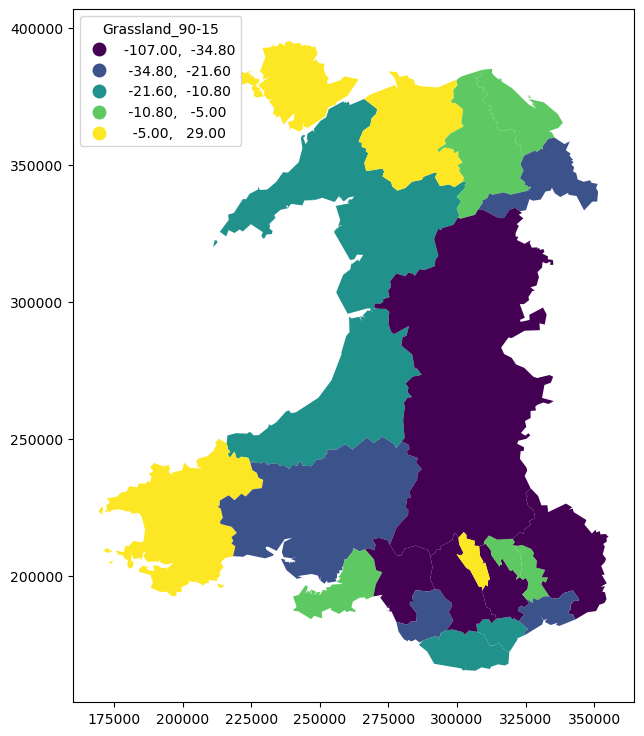

In [21]:
col='Grassland_90-15'

fig, ax = plt.subplots(1, figsize=(9, 9))

wales_gpd.plot(column=col, cmap='viridis', 
        scheme='quantiles', k=5, 
        linewidth=0., 
        legend=True, legend_kwds={"title":col,"loc": 2},
        ax=ax
       )

plt.show()

### Improving maps of change


What do you think of this map? Can we do better? Yes, we can!

The slide at 12:47 mins in the [ialeUK video](https://youtu.be/NZZvE6OH9bI?t=767) talks about poor symbolisation. 

Let's produce a map of grassland change 1990-2015 in Wales with better symbolisation _and for a better variable_. Specifically, we will:
1. plot a _spatially intensive_ variable of grassland change (i.e. percentage change, not absolute change) 
2. use a divergent colour scheme that appropriately represents increase vs decrease in grassland 

The concepts we are working with here were covered in Section 6 of the Foundations of SDS module.

In [22]:
wales_gpd.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 22 entries, Isle of Anglesey to Merthyr Tydfil
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   OBJECTID         22 non-null     int32   
 1   ctyua19cd        22 non-null     object  
 2   ctyua19nmw       22 non-null     object  
 3   bng_e            22 non-null     int32   
 4   bng_n            22 non-null     int32   
 5   long             22 non-null     float64 
 6   lat              22 non-null     float64 
 7   GlobalID         22 non-null     object  
 8   SHAPE_Length     22 non-null     float64 
 9   SHAPE_Area       22 non-null     float64 
 10  geometry         22 non-null     geometry
 11  No Data15        6 non-null      float64 
 12  Woodland15       22 non-null     int64   
 13  Cropland15       19 non-null     float64 
 14  Grassland15      22 non-null     int64   
 15  Water15          13 non-null     float64 
 16  Built-up15      

In [23]:
# create a variable for the total area of each county
wales_gpd['Sum15'] = wales_gpd.loc[:,'Woodland15':'Other15'].sum(axis=1)   #axis=1 to sum rows
# calclate the percentage change
wales_gpd['Grassland_90-15Perc'] = 100* wales_gpd['Grassland_90-15'] / wales_gpd['Sum15']

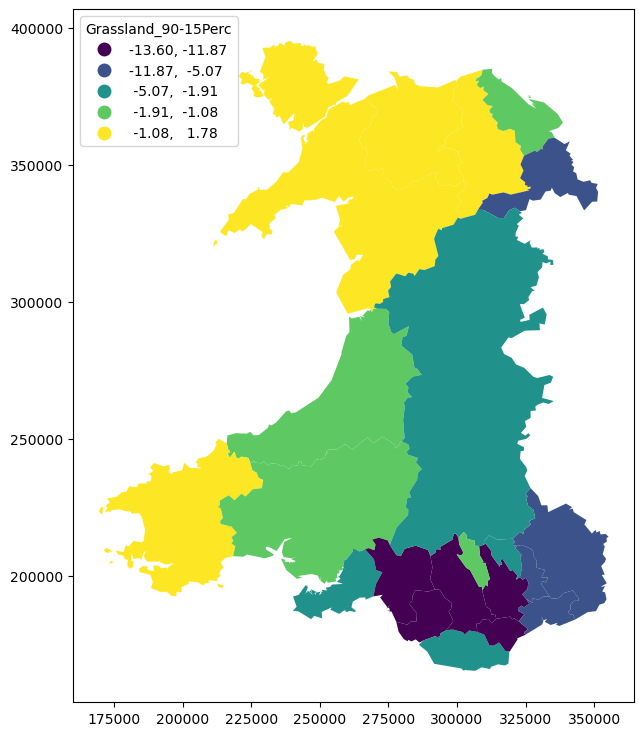

In [24]:
# get it plotted
col='Grassland_90-15Perc'

fig, ax = plt.subplots(1, figsize=(9, 9))

wales_gpd.plot(column=col, cmap='viridis', 
        scheme='quantiles', k=5, 
        linewidth=0., 
        legend=True, legend_kwds={"title":col,"loc": 2},
        ax=ax
       )

plt.show()

That produces a very different map!

And now let's do a diverging colour palette. We could use (1) a built-in palette, this doesn't set zero at the centre of the scale: 

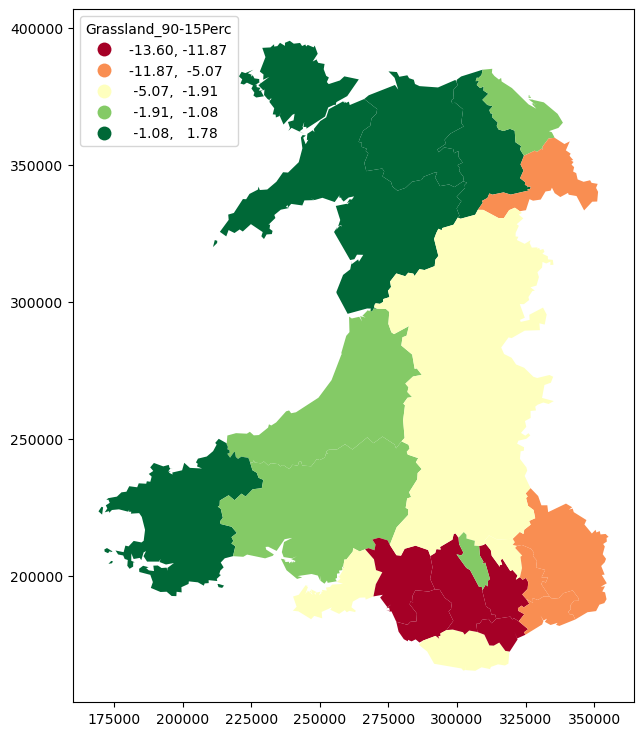

In [25]:
col='Grassland_90-15Perc'

fig, ax = plt.subplots(1, figsize=(9, 9))

wales_gpd.plot(column=col, cmap='RdYlGn', 
        scheme='quantiles', k=5, 
        linewidth=0., 
        legend=True, legend_kwds={"title":col,"loc": 2},
        ax=ax
       )

plt.show()

We can do (2) a `UserDefined` classification scheme along with our own `ListedColormap`, on basis of checking the distribution of our variable to decide what classfication and color scheme. 

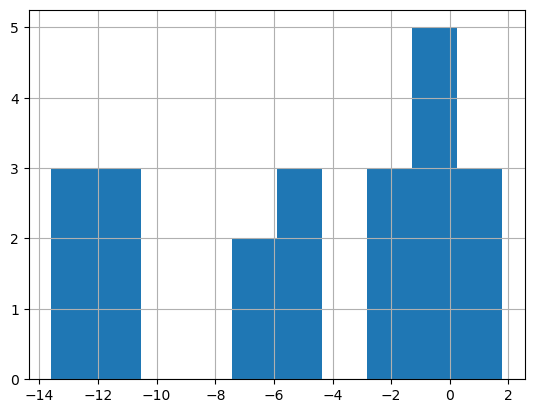

In [26]:
#plot histogram
wales_gpd['Grassland_90-15Perc'].hist()
plt.show()

To create our own classification we'll use `mapclassify.UserDefined` which [expects](https://pysal.org/mapclassify/generated/mapclassify.UserDefined.html#mapclassify.UserDefined) upper bounds of class bins. 

Let's do five bins, with four <0 and one >0:

In [27]:
#bins from histogram check above but centred on zero
grassbins = [-14,-10,-6, -2,0,2]  #mapclassify.UserDefined requires upper bounds of class bins 

Now create our own colour map with reds for negative change and greens for positive, using color codes from [colorbrewer2.org](https://colorbrewer2.org). We'll take [colours from a 8-class diverging scheme](https://colorbrewer2.org/#type=diverging&scheme=RdYlGn&n=8) as we want four red hue colours (for <0): 

In [28]:
#create colormap to match bins
grasscmap = ListedColormap(["#d73027","#f46d43", "#fdae61", "#fee08b", "#d9ef8b", '#a6d96a'])

And now we use these bin limits and colors with our usual plotting function:

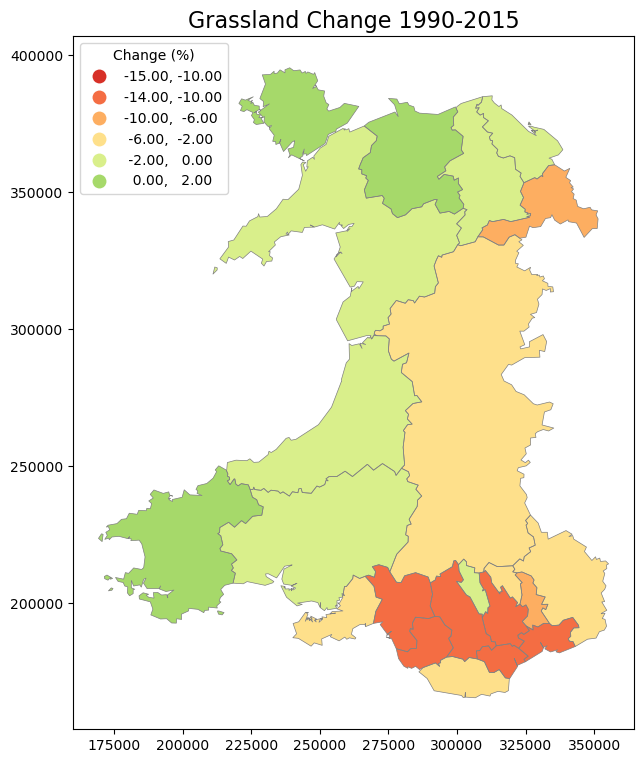

In [29]:
#make the county-level plot
fig, ax = plt.subplots(1, figsize=(9, 9))

wales_gpd.plot(column='Grassland_90-15Perc', 
    cmap=grasscmap, 
    scheme='UserDefined', 
    classification_kwds={'bins': grassbins},  #provide the user-created (upper) bin limits here
    legend=True, legend_kwds={"title":"Change (%)","loc": 2}, ax=ax
)

wales_gpd.plot(ax=ax, facecolor='None', edgecolor='grey', linewidth=0.5)

#edit legend labels
leg = ax.get_legend()
leg.get_texts()[0].set_text('-15.00, -10.00')

plt.title("Grassland Change 1990-2015", size=16)
plt.show()

Hopefully you agree that this map is more appropriate for representing county-level change than those we saw in the video and made above!

#### TASK

Create a county-level woodland change choropleth map for 1990-2015. Your maps should have appropriate and consistent classification and colour scheme. Your final plot should look something like this:

<img src="https://www.landscapemodelling.net/png/woodland-change-1990-2015.png" width="300px"></img>

<Axes: >

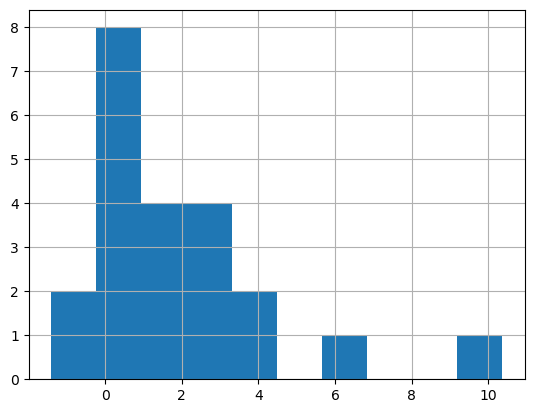

In [30]:
#calculate absolute change
wales_gpd['Woodland_90-15'] = wales_gpd['Woodland15'] - wales_gpd['Woodland90']

# calclate the percentage change
wales_gpd['Woodland_90-15Perc'] = 100* wales_gpd['Woodland_90-15'] / wales_gpd['Sum15']

#plot histogram
wales_gpd['Woodland_90-15Perc'].hist()

In [31]:
#bins from histogram check above but centred on zero
woodbins = [0,2,4,8,12]  

#create colormap to match bins
woodcmap = ListedColormap(["#fee08b", "#d9ef8b", "#a6d96a", "#66bd63", "#1a9850", "#006837"])

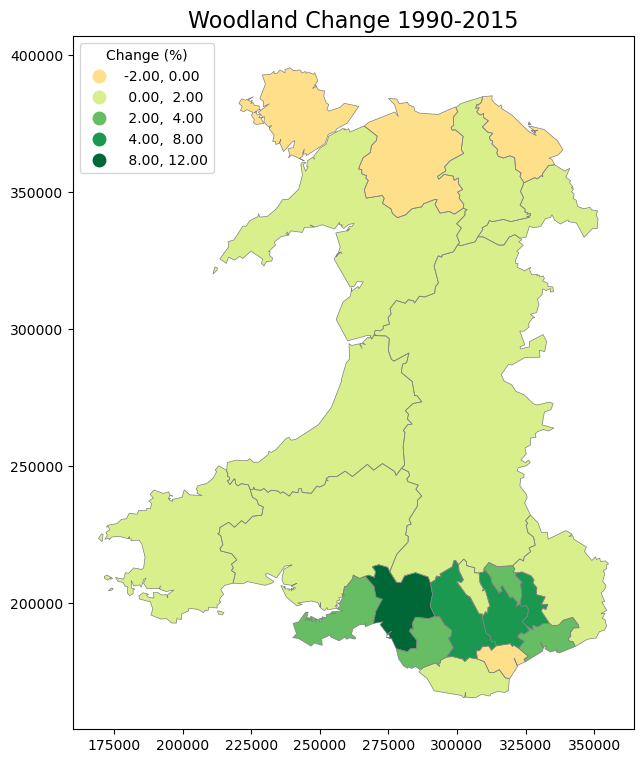

In [32]:
#make the county-level plot
fig, ax = plt.subplots(1, figsize=(9, 9))

wales_gpd.plot(column='Woodland_90-15Perc', 
    cmap=woodcmap, 
    scheme='UserDefined', 
    classification_kwds={'bins': woodbins},  #provide the user-created (upper) bin limits here
    legend=True, legend_kwds={"title":"Change (%)","loc": 2}, ax=ax
)

wales_gpd.plot(ax=ax, facecolor='None', edgecolor='grey', linewidth=0.5)

leg = ax.get_legend()
leg.get_texts()[0].set_text('-2.00, 0.00')

plt.title("Woodland Change 1990-2015", size=16)
plt.show()

<a name="section3"></a>
## 3. Landscape Pattern Analysis

This section assumes you have worked through the Landscape Pattern notebook available on KEATS.

## Landscape Metrics

For landscapes categorised into discrete classes of land cover or land use, and represented by raster data (i.e. grids of pixels), **landscape metrics** can be used to measure or characterise the spatial composition and configuration (i.e. pattern) of those classes.

Here we will examine landscape pattern across Wales (a 1km resolution) for 1990 and 2015, focusing primarily on the Grassland and Woodland classes. 

First, we need to create a `Landscape` object. We can do this from our `numpy array` (specifying the spatial resolution of the data). And we can optionally plot a map:

<Axes: >

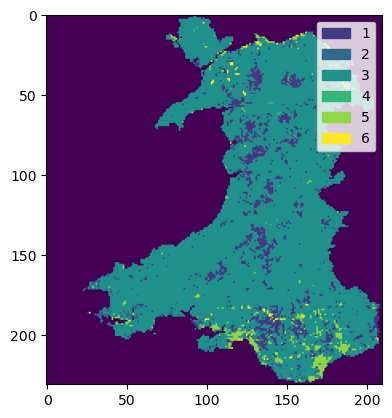

In [33]:
lsp1990 = pls.Landscape(lcm1990_wales6, res=(1000,1000))
lsp1990.plot_landscape(legend=True)

To calculate pattern metrics at the landscape-level for 1990:

In [34]:
lsp1990_lsp_df = lsp1990.compute_landscape_metrics_df(metrics=
                                 ["number_of_patches",
                                  "edge_density",
                                  "area_mn",
                                  "euclidean_nearest_neighbor_mn"]
                                )
lsp1990_lsp_df

,number_of_patches,edge_density,area_mn,euclidean_nearest_neighbor_mn
0,726,2.788554,2854.545455,4070.254181


#### TASK
Check you understand what the metrics are that have just been calculated. For example, what does _area_mn_ calculate?

In [35]:
#answer!
#area_mn is the mean (mn) patch area across the entire landscape 
#as described here: https://pylandstats.readthedocs.io/en/latest/landscape.html#pylandstats.Landscape.area
#and here: https://pylandstats.readthedocs.io/en/latest/landscape.html#list-of-implemented-metrics

#### TASK 

Calculate the same landscape-level metrics for 2015 as have just been calculated for 1990 (you will need to create a `Landscape` object first)  

In [36]:
#answer!
lsp2015 = pls.Landscape(lcm2015_wales6, res=(1000,1000))
lsp2015_lsp_df = lsp2015.compute_landscape_metrics_df(metrics=
                                 ["number_of_patches",
                                  "edge_density",
                                  "area_mn",
                                  "euclidean_nearest_neighbor_mn"]
                                )
lsp2015_lsp_df

,number_of_patches,edge_density,area_mn,euclidean_nearest_neighbor_mn
0,793,3.107627,2622.194199,3998.403057


#### TASK

Answer the following questions about differences between 2015 and 1990:

1. Did the total number of number of patches in the landscape increase or decrease between 1990 and 2015?
2. Was edge density higher in 1990 or 2015?
3. In which year was mean patch area greatest?

In [37]:
#
#1. increased (726 vs 793
#2. 2015 (3.108)
#3. 1990 (2855)

To calculate metrics at the class-level we use the `compute_class_metrics_df` method on our `Landscape` object: 

In [38]:
lsp1990_class_df = lsp1990.compute_class_metrics_df(
        metrics=["proportion_of_landscape", "number_of_patches", 
                 "edge_density", "area_mn", "euclidean_nearest_neighbor_mn"]
)
lsp1990_class_df=lsp1990_class_df.rename(index=idlabs)
lsp1990_class_df

,proportion_of_landscape,number_of_patches,edge_density,area_mn,euclidean_nearest_neighbor_mn
class_val,,,,,
Woodland,8.550473,328,1.744837,540.243902,3142.892662
Cropland,1.823972,151,0.436209,250.331126,4195.584609
Grassland,86.035514,33,2.644760,54030.303030,2325.068308
Water,0.207489,22,0.065624,195.454545,12266.380098
Built-up,2.933797,145,0.566493,419.310345,4515.575336
Other,0.448755,47,0.119185,197.872340,6154.392047


#### TASK 

Calculate the same class metrics for the 2015 landscape.

In [39]:
#answer!
lsp2015_class_df = lsp2015.compute_class_metrics_df(
        metrics=["proportion_of_landscape", "number_of_patches", 
                 "edge_density", "area_mn", "euclidean_nearest_neighbor_mn"]
)
lsp2015_class_df=lsp2015_class_df.rename(index=idlabs)
lsp2015_class_df

,proportion_of_landscape,number_of_patches,edge_density,area_mn,euclidean_nearest_neighbor_mn
class_val,,,,,
Woodland,9.844186,369,1.931807,554.742547,2980.069229
Cropland,2.250649,176,0.552563,265.909091,3620.853985
Grassland,83.519284,32,2.871501,54271.875000,2285.386216
Water,0.240454,26,0.074541,192.307692,11103.098886
Built-up,3.866500,153,0.710782,525.490196,4637.339026
Other,0.278927,37,0.074060,156.756757,9797.080443


Because there are more rows (one per class) it is more difficult to compare class metrics across two tables. However, `pylandstats` has functionality to facilitate spatio-temporal analysis that makes things a little easier - let's see that now

### Spatio Temporal Analysis

To use the [spatio-temporal functionality in `pylandstats`](https://pylandstats.readthedocs.io/en/latest/spatiotemporal.html) we need to create a `SpatioTemporalAnalysis` object from some `Landscape` objects. We also optionally pass values that correspond to the dates of the `Landscape` objects: 

In [40]:
st9015 = pls.SpatioTemporalAnalysis(landscapes=[lsp1990, lsp2015],
                                    dates=[1990,2015])

Now, we can calculate landscape metrics for multuple landscapes at the same time, using the `compute_landscape_metrics_df` method on the `SpatioTemporalAnalysis` object:  

In [41]:
st9015_lsp_df = st9015.compute_landscape_metrics_df(metrics=
                                 ["number_of_patches",
                                  "edge_density",
                                  "area_mn",
                                  "euclidean_nearest_neighbor_mn"]
                                )
st9015_lsp_df

[########################################] | 100% Completed | 108.48 ms


,number_of_patches,edge_density,area_mn,euclidean_nearest_neighbor_mn
dates,,,,
1990,726,2.788554,2854.545455,4070.254181
2015,793,3.107627,2622.194199,3998.403057


Note how we now have metrics for both years in the same table (without us needing to combine the tables together manually). 

Now that we have a `SpatioTemporalAnalysis` object we can also plot how any given metric changes between the landscapes:  

[########################################] | 100% Completed | 107.59 ms


<Axes: ylabel='NP'>

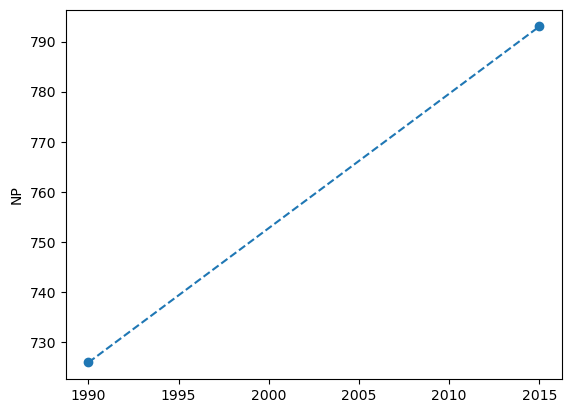

In [42]:
st9015.plot_metric(metric="number_of_patches")

This plot is fine as a quick way to visualise values, but we can do better (as we will see below). 

### TASK 

Using the same `SpatioTemporalAnalysis` object as above, create a dataframe of the class-level metrics for the two years:

In [43]:
#answer!
st9015_class_df = st9015.compute_class_metrics_df(
        metrics=["proportion_of_landscape", "number_of_patches", 
                 "edge_density",  "area_mn", "euclidean_nearest_neighbor_mn"]
                                )
st9015_class_df=st9015_class_df.rename(index=idlabs)
st9015_class_df

[########################################] | 100% Completed | 107.82 ms


proportion_of_landscape  number_of_patches  edge_density  \
class_val dates                                                             
Woodland  1990                  8.550473                328      1.744837   
          2015                  9.844186                369      1.931807   
Cropland  1990                  1.823972                151      0.436209   
          2015                  2.250649                176      0.552563   
Grassland 1990                 86.035514                 33      2.644760   
          2015                 83.519284                 32      2.871501   
Water     1990                  0.207489                 22      0.065624   
          2015                  0.240454                 26      0.074541   
Built-up  1990                  2.933797                145      0.566493   
          2015                  3.866500                153      0.710782   
Other     1990                  0.448755                 47      0.119185   
          2015                  0.278927                 37      0.074060   

                      area_mn  euclidean_nearest_neighbor_mn  
class_val dates                                               
Woodland  1990     540.243902                    3142.892662  
          2015     554.742547                    2980.069229  
Cropland  1990     250.331126                    4195.584609  
          2015     265.909091                    3620.853985  
Grassland 1990   54030.303030                    2325.068308  
          2015   54271.875000                    2285.386216  
Water     1990     195.454545                   12266.380098  
          2015     192.307692                   11103.098886  
Built-up  1990     419.310345                    4515.575336  
          2015     525.490196                    4637.339026  
Other     1990     197.872340                    6154.392047  
          2015     156.756757                    9797.080443

The class-level dataframe has a [multi-index](https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html), one for land cover class and one for year. Look back to [the pandas docs on indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html) if you need a reminder (we covered them in week 3 of Foundations of SDS). 

Using [the `unstack` method on the multi-indexed dataframe](https://pandas.pydata.org/docs/user_guide/reshaping.html#reshaping-stacking) with pandas plotting allows to quickly produce a grouped barplot: 

<Axes: xlabel='class_val', ylabel='Number of Patches'>

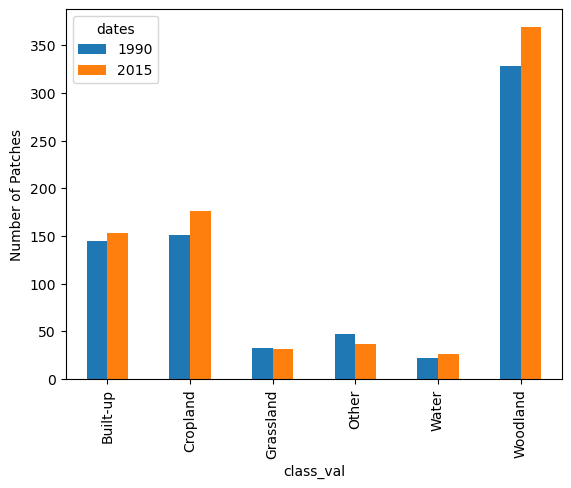

In [44]:
st9015_class_df["number_of_patches"].unstack().plot.bar(ylabel="Number of Patches")

This is much better than the quick plot of metrics from `pylandsats`!

#### TASK
Create a grouped plot as above but for _Edge Density_:

<Axes: xlabel='class_val', ylabel='Edge Density'>

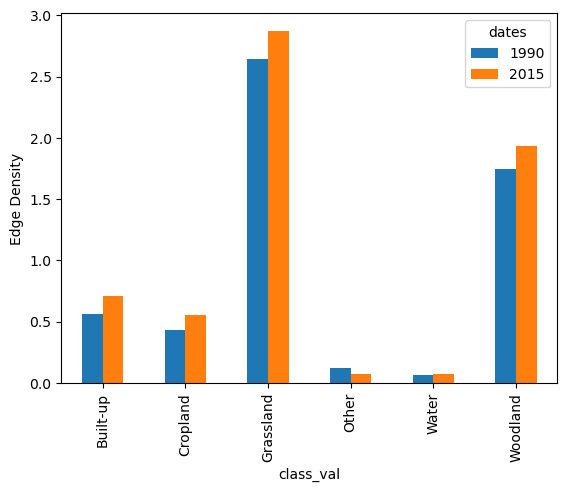

In [45]:
#answer!
st9015_class_df["edge_density"].unstack().plot.bar(ylabel="Edge Density")

#### TASK

In your own words, explain why _Edge Density_ is greater for Grassland than Woodland (in both years), despite Woodland having many more patches.

**answer!**
because Grassland patches are so much larger (compare area_mn between Grassland and Woodland) the amount of edge they have overall is much greater 

<a name="section4"></a>
## 4. Analysing Pixel-by-Pixel Change 

The analysis above was into zones (in our case, counties) or considering patches (spatially contiguous groups of pixels of the same type). At the finest level of analysis we can analyse change for individual pixels. 

For example, we could count the number of pixel transitions between the different classes - how many pixels were Grassland in 1990 but Woodland in 2015, how many were Grassland in 1990 but Urban in 2015, how many were Woodland in 1990 but Arable in 2015... etc. 

In this section we will calculate all possible transitions using a [contingency table](https://en.wikipedia.org/wiki/Contingency_table) (also known as _cross-tabulation_ or _confusion matrix_). This table can then be used to visualise all the transitions using a _Sankey Diagram_ (like in Clare Rowland's talk ([at 14:55](https://youtu.be/NZZvE6OH9bI?t=895)). Creating the contingency table is shown in this notebook, with code to make the Sankey Diagram shown in a separate notebook.   

### Contingency Table

First, we do the cross tabulation. This is relatively straight-forward using the [`confusion_matrix` function](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix) from the `sklearn` package.

We need to `flatten` our 2D `ndarray` to 1D to allow `confusion_matrix` to compare the two maps:

In [46]:
lcm1990_wales6_f = lcm1990_wales6.flatten()  #flatten from 2d to 1D
lcm2015_wales6_f = lcm2015_wales6.flatten()  #flatten from 2d to 1D

print(lcm1990_wales6_f.shape)

(48510,)


Now pass the two flattened maps (i.e. 1D `ndarray`s) to the `confusion_matrix` function:

In [47]:
#from sklearn import metrics
confND = metrics.confusion_matrix(lcm1990_wales6_f, lcm2015_wales6_f)
print(confND.shape)
print('\n')
print(confND)

(7, 7)


[[27716     0     7    49     0    11     3]
 [    0  1606     2   144     1    17     2]
 [    0     8   169   187     0    11     3]
 [    0   413   283 16922     4   188    20]
 [    0     1     0     4    38     0     0]
 [    0     9     2    21     4   572     0]
 [    0    10     5    40     3     5    30]]


From [the docs](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix), the result is a:
> confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.

So for us, this means 1990 values are rows, with the corrsponding 2015 value in columns. 

Remember that the data we used still had the 'No Data' `0` values, so the first row and column are transitions to/from 'No Data'. We could make the contingency table clearer by removing the `No Data` transitions. A short function for this might be as follows:

In [48]:
def stripFirstRows(mydat):
    
    stripped = np.delete(arr=mydat, obj=0, axis=0)     #delete 0-th row
    stripped = np.delete(arr=stripped, obj=0, axis=1)  #delete 0-th col
    
    return stripped

Then using that function:

In [49]:
conf = stripFirstRows(confND)

print(conf.shape)
print('\n')
print(conf)

(6, 6)


[[ 1606     2   144     1    17     2]
 [    8   169   187     0    11     3]
 [  413   283 16922     4   188    20]
 [    1     0     4    38     0     0]
 [    9     2    21     4   572     0]
 [   10     5    40     3     5    30]]


This is better (and we'll use this `ndarray` object again below) but we could make things easier for ourselves by converting to a Pandas `DataFrame` and providing labels for rows (i.e. an index) and column names:

In [50]:
conf_pd = pd.DataFrame(conf,index=lclabels[1:],columns=lclabels[1:])
conf_pd

,Woodland,Cropland,Grassland,Water,Built-up,Other
Woodland,1606,2,144,1,17,2
Cropland,8,169,187,0,11,3
Grassland,413,283,16922,4,188,20
Water,1,0,4,38,0,0
Built-up,9,2,21,4,572,0
Other,10,5,40,3,5,30


Check you understand the structure of this contingency table. Remember, 1990 values are rows, with the corrsponding 2015 value in columns. 

For example, check you can see how it shows that 144 cells transitioned from Woodland to Grassland, while 413 cells transitioned from Grassland to Woodland. 

How many cells transitioned from Other to Grassland?

**Answer: 40**

## Exercise

Repeat the analyses we have done over the last two weeks for Scotland:
- read in the UK data
- crop for scotland only
- calculate land cover composition and change (1990-2105) across the whole of scotland
- calculate zonal composition and Woodland change for Scotland counties
- compare landscape pattern between 1990-2015 in Scotland
- identify the most frequent pixel transition between 1990 and 2015   

In [51]:
#your code
import rasterio
# read in scotland boundary
lads = gpd.read_file("data/Countries_(December_2022)_GB_BUC.geojson").set_index('FID')
lads_reproj  = lads.to_crs({'init': 'epsg:27700'})
lads_reproj_scotland=lads_reproj[lads_reproj['CTRY22NM']=='Scotland']

# crop raster images by scotland country boundary
lcm1990_new = rio.open("data/lcm1990-BNG.tif")
lcm2015_new = rio.open("data/lcm2015-BNG.tif")

lcm1990_scotland, lcm1990_scotland_transform = rasterio.mask.mask(dataset=lcm1990_new, 
                                                            shapes=lads_reproj_scotland.geometry, 
                                                            crop=True)

lcm2015_scotland, lcm2015_scotland_transform = rasterio.mask.mask(dataset=lcm2015_new, 
                                                            shapes=lads_reproj_scotland.geometry, 
                                                            crop=True)

# write cropped raster images into files

#function to write ndarray to file as a .tif (with CRS etc)
def write_nd_to_tif(nd, meta, transform, filename):
    
    #update meta from original to new data extent and transform 
    meta.update({"driver": "GTiff",
                 "height": nd.shape[1],
                 "width": nd.shape[2],
                 "transform": transform})

    with rasterio.open(filename, "w", **meta) as dest:
        dest.write(nd)

# write to files
write_nd_to_tif(nd=lcm1990_scotland, 
                meta=lcm1990_new.meta, 
                transform=lcm1990_scotland_transform, 
                filename="data/lcm1990_scotland.tif")

write_nd_to_tif(nd=lcm2015_scotland, 
                meta=lcm2015_new.meta, 
                transform=lcm2015_scotland_transform, 
                filename="data/lcm2015_scotland.tif")

In [52]:
# reclassify land covers

#read data
lcm1990_scotland = rio.open('data/lcm1990_scotland.tif')
lcm2015_scotland = rio.open('data/lcm2015_scotland.tif')

lcm1990_scotland_np = lcm1990_scotland.read(1)
lcm2015_scotland_np = lcm2015_scotland.read(1)

import copy
lcm2015_scotland6 = copy.deepcopy(lcm2015_scotland_np)
lcm1990_scotland6 = copy.deepcopy(lcm1990_scotland_np)

# reclassify from 21 to 6
lookup = {1:1,2:1,
          3:2,
          4:3,5:3,6:3,7:3,8:3,9:3,10:3,11:3,16:3,18:3,19:3,
          14:4,
          20:5,21:5,
          12:6,13:6,15:6,17:6}

# modify values in both land cover maps
for old, new in lookup.items(): 
    lcm2015_scotland6[lcm2015_scotland_np == old]=new
    lcm1990_scotland6[lcm1990_scotland_np == old]=new

# writing reclassified raster images to file

lcm1990_scotland6_out = lcm1990_scotland6.reshape(1, *lcm1990_scotland6.shape)  
lcm2015_scotland6_out = lcm2015_scotland6.reshape(1, *lcm2015_scotland6.shape) 

write_nd_to_tif(lcm1990_scotland6_out,  lcm1990_new.meta, lcm1990_scotland_transform, "data/lcm1990_scotland6.tif")
write_nd_to_tif(lcm2015_scotland6_out, lcm2015_new.meta, lcm2015_scotland_transform, "data/lcm2015_scotland6.tif")

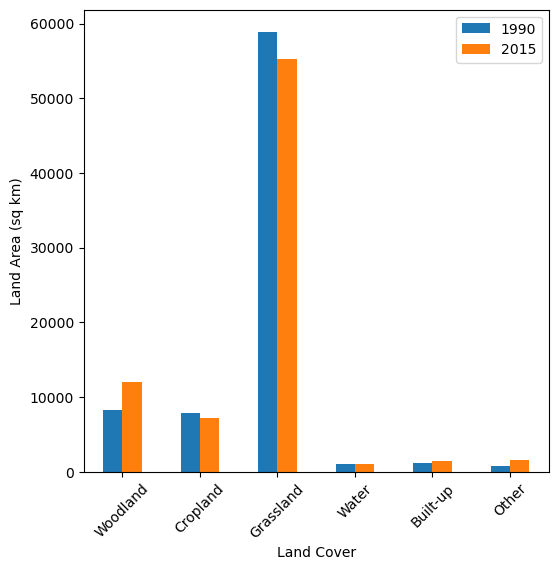

In [53]:
# analysing aggregate changes
unique, counts = np.unique(lcm1990_scotland6, return_counts=True) 
counts1990_6 = dict(zip(unique, counts))   
unique1, counts1 = np.unique(lcm2015_scotland6, return_counts=True) 
counts2015_6 = dict(zip(unique1, counts1))

lcs = ['No Data', 'Woodland', 'Cropland', 'Grassland', 'Water', 'Built-up', 'Other'] 
lclabs = dict(zip(np.arange(0,7).tolist(), lcs))

counts_df = pd.DataFrame.from_dict([lclabs,counts1990_6,counts2015_6]).T

counts_df.columns = ['Land Cover', '1990', '2015']

fig, axs = plt.subplots(1, figsize=(6,6))

counts_df[counts_df['Land Cover']!='No Data'].plot.bar(
    ax=axs, xlabel="Land Cover", ylabel='Land Area (sq km)')

axs.set_xticklabels(labels= lcs[1:], rotation=45)

plt.show()

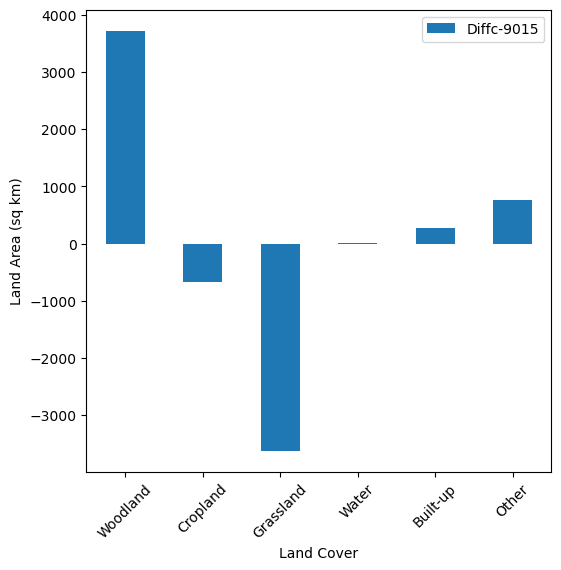

In [54]:
counts_df['Diffc-9015'] = counts_df['2015'] - counts_df['1990']
fig, axs = plt.subplots(1, figsize=(6,6))

counts_df[counts_df['Land Cover']!='No Data'][['Diffc-9015']].plot.bar(
    ax=axs, xlabel="Land Cover", ylabel='Land Area (sq km)')

axs.set_xticklabels(labels= lcs[1:], rotation=45)

plt.show()

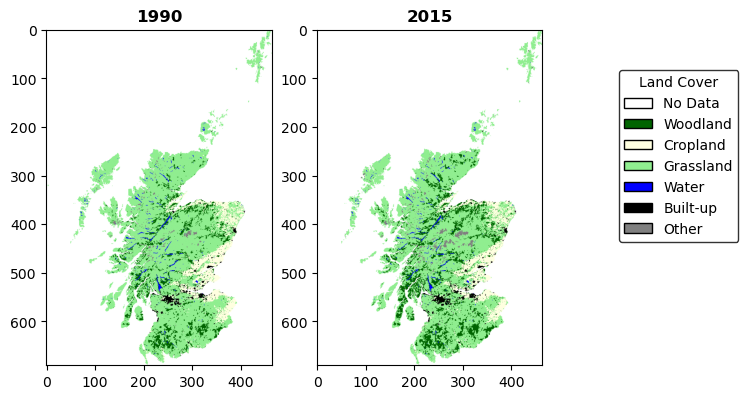

In [55]:
# plotting categorical changes
#define legend based on provided information
#legend mapping land cover values to class names
legend_dict = {
    0: ['No Data', 'white'],
    1: ['Woodland', 'darkgreen'],
    2: ['Cropland', 'lightyellow'],
    3: ['Grassland', 'lightgreen'],
    4: ['Water', 'blue'],
    5: ['Built-up', 'black'],
    6: ['Other', 'grey'],
}

#create colormap using colours specified in the legend dict
colors = [legend_dict[key][1] for key in sorted(legend_dict.keys())]
lcmap = ListedColormap(colors)

#create list of ids (in the raster) from the legend keys, adding an upper bound greater than current largest
bounds = list(legend_dict.keys())
bounds.append(bounds[-1] + 1)

#create a BoundaryNorm object to scale the colormap to the legend values, e.g. https://stackoverflow.com/a/14779462
bnorm = BoundaryNorm(bounds, lcmap.N)

#create colour boxes and labels for the map legend from the legend_dict 
colourboxes = [plt.Rectangle(xy=(0, 0),width=1,height=1, 
                         facecolor=legend_dict[key][1],edgecolor='black') for key in sorted(legend_dict.keys())]
lclabels = [f"{legend_dict[key][0]}" for key in sorted(legend_dict.keys())]

#create the actual plot
fig, axs = plt.subplots(1, 2)

#plot a map on each axes
show(source=lcm1990_scotland6, cmap=lcmap, norm=bnorm, title="1990", ax=axs[0])
show(source=lcm2015_scotland6, cmap=lcmap, norm=bnorm, title="2015", ax=axs[1])

#plot single legend (on one axes, using bbox_to_anchor to position)
legend = axs[1].legend(handles=colourboxes, 
                       labels=lclabels, 
                       bbox_to_anchor=(1.9, 0.9),
                      title="Land Cover",
                      edgecolor='black')

#print plot
plt.show()

In [56]:
# prepare the zonal boundary, which are counties in Scotland
scotland = GB[GB['ctyua19cd'].str.startswith("S")]
# read in the classified data
lcm1990_scotland6_dr=rio.open("data/lcm1990_scotland6.tif")
lcm2015_scotland6_dr=rio.open("data/lcm2015_scotland6.tif")

# calculate zonal composition and Woodland change for Scotland counties
zs_scotland15_6 = zonal_stats(scotland, lcm2015_scotland6,
                           affine=lcm2015_scotland6_dr.meta['transform'],
                           categorical=True)
zs_scotland90_6 = zonal_stats(scotland, lcm1990_scotland6,
                           affine=lcm1990_scotland6_dr.meta['transform'],
                           categorical=True)

#convert the zonal stats dict to a dataframe
zs_scotland15_6_pd = pd.DataFrame(zs_scotland15_6)
zs_scotland90_6_pd = pd.DataFrame(zs_scotland90_6)

#set the index to be the same as `scotland` for later joining
zs_scotland15_6_pd.set_index(scotland.index,inplace=True)
zs_scotland90_6_pd.set_index(scotland.index,inplace=True)

#use the idlabs dict we created above
zs_scotland15_6_pd.rename(columns=idlabs,inplace=True) 
zs_scotland90_6_pd.rename(columns=idlabs,inplace=True) 

#set column names with `15` suffix to distinguish from other years' data
zs_scotland15_6_pd = zs_scotland15_6_pd.add_suffix('15')
zs_scotland90_6_pd = zs_scotland90_6_pd.add_suffix('90')
#join to wales `GeoDataFrame` by creating a new object 
scotland_gpd = pd.merge(scotland, zs_scotland15_6_pd, how='left', left_index=True, right_index=True)
scotland_gpd = pd.merge(scotland_gpd, zs_scotland90_6_pd, how='left', left_index=True, right_index=True)
scotland_gpd 

,OBJECTID,ctyua19cd,ctyua19nmw,bng_e,bng_n,long,lat,GlobalID,SHAPE_Length,SHAPE_Area,...,No Data15,Water15,Other15,Woodland90,Cropland90,Grassland90,Built-up90,No Data90,Water90,Other90
ctyua19nm,,,,,,,,,,,,,,,,,,,,,
Clackmannanshire,163,S12000005,,291159,696335,-3.75344,56.147240,{6FADB854-BE30-49A0-BB99-985FD1C9B2A5},0.981264,0.023022,...,NaN,NaN,NaN,9.0,43.0,92,13,NaN,NaN,NaN
Dumfries and Galloway,164,S12000006,,270645,579856,-4.02863,55.096210,{1625C4E0-44F1-46D9-88D7-4630A51F4B53},8.532110,0.906698,...,4.0,19.0,13.0,1288.0,191.0,4881,23,20.0,21.0,19.0
East Ayrshire,165,S12000008,,255398,624935,-4.29057,55.496738,{91F1886E-B2E1-4E3C-B9E7-96585BE22F9F},3.463673,0.180878,...,NaN,8.0,21.0,168.0,2.0,1079,21,NaN,9.0,3.0
East Lothian,166,S12000010,,354854,672351,-2.72435,55.942070,{3D82E9A3-6A2B-4FB4-BF8E-307E1BB2C8C7},1.992119,0.097593,...,2.0,1.0,NaN,15.0,450.0,184,18,5.0,1.0,1.0
East Renfrewshire,167,S12000011,,251929,653115,-4.36060,55.748680,{5A6D1055-9711-43AE-AECA-892C7FCDAB5E},0.960991,0.025136,...,NaN,NaN,1.0,1.0,NaN,148,21,NaN,NaN,NaN
Na h-Eileanan Siar,168,S12000013,,126473,932862,-6.65722,58.199379,{F3734E55-ECA4-4B11-BF7E-28FD314A827A},21.991962,0.458901,...,35.0,55.0,62.0,3.0,NaN,2862,1,67.0,56.0,27.0
Falkirk,169,S12000014,,289661,679536,-3.77060,55.996040,{75DABF29-C24F-4423-BA2E-21EC03965DCD},1.608756,0.042723,...,NaN,NaN,2.0,16.0,85.0,137,54,NaN,NaN,2.0
Highland,170,S12000017,,241018,858292,-4.66103,57.586571,{1BC09815-E0CD-45CC-BA81-5E2D49CFBA5E},38.000287,3.946333,...,160.0,560.0,862.0,2294.0,402.0,22206,36,257.0,557.0,543.0
Inverclyde,171,S12000018,,227922,670894,-4.75387,55.900299,{567AA311-374F-46C4-8EA5-DC372AB299C8},0.819552,0.023324,...,NaN,3.0,1.0,16.0,NaN,125,19,3.0,1.0,1.0


<Axes: >

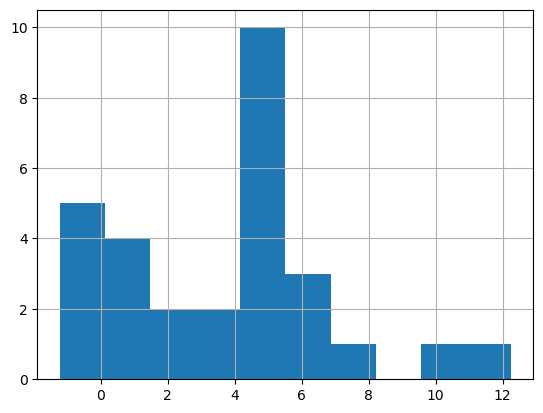

In [57]:
# calculate the woodland change of scotland from 1990-2015
# create a variable for the total area of each county
scotland_gpd['Sum15'] = scotland_gpd.loc[:,'Woodland15':'Other15'].sum(axis=1)   #axis=1 to sum rows
#calculate absolute change
scotland_gpd['Woodland_90-15'] = scotland_gpd['Woodland15'] - scotland_gpd['Woodland90']

# calclate the percentage change
scotland_gpd['Woodland_90-15Perc'] = 100* scotland_gpd['Woodland_90-15'] / scotland_gpd['Sum15']

#plot histogram
scotland_gpd['Woodland_90-15Perc'].hist()

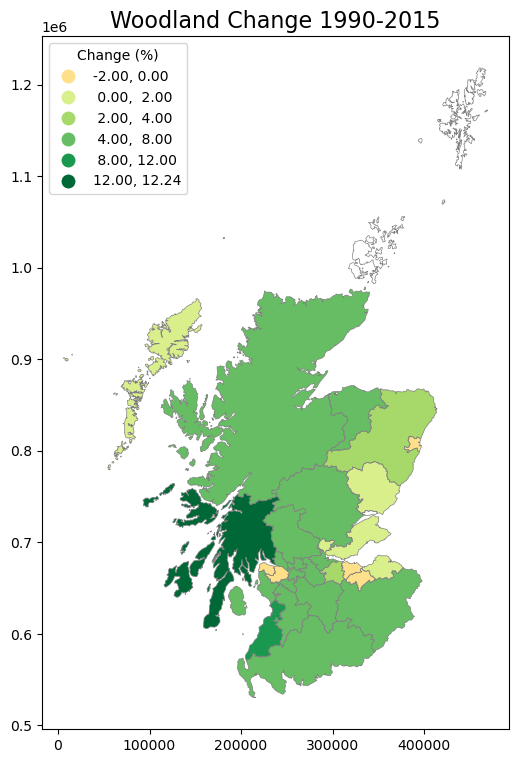

In [58]:
#bins from histogram check above but centred on zero
woodbins = [0,2,4,8,12]  

#create colormap to match bins
woodcmap = ListedColormap(["#fee08b", "#d9ef8b", "#a6d96a", "#66bd63", "#1a9850", "#006837"])

#make the county-level plot
fig, ax = plt.subplots(1, figsize=(9, 9))

scotland_gpd.plot(column='Woodland_90-15Perc', 
    cmap=woodcmap, 
    scheme='UserDefined', 
    classification_kwds={'bins': woodbins},  #provide the user-created (upper) bin limits here
    legend=True, legend_kwds={"title":"Change (%)","loc": 2}, ax=ax
)

scotland_gpd.plot(ax=ax, facecolor='None', edgecolor='grey', linewidth=0.5)

leg = ax.get_legend()
leg.get_texts()[0].set_text('-2.00, 0.00')

plt.title("Woodland Change 1990-2015", size=16)
plt.show()

In [59]:
# Compare landscape patterns

# prepare 2015
lsp2015 = pls.Landscape(lcm2015_scotland6, res=(1000,1000))
lsp2015_lsp_df = lsp2015.compute_landscape_metrics_df(metrics=
                                 ["number_of_patches",
                                  "edge_density",
                                  "area_mn",
                                  "euclidean_nearest_neighbor_mn"]
                                )

lsp2015_class_df = lsp2015.compute_class_metrics_df(
        metrics=["proportion_of_landscape", "number_of_patches", 
                 "edge_density", "area_mn", "euclidean_nearest_neighbor_mn"]
)
lsp2015_class_df=lsp2015_class_df.rename(index=idlabs)

# prepare 1990
lsp1990 = pls.Landscape(lcm1990_scotland6, res=(1000,1000))
lsp1990_lsp_df = lsp1990.compute_landscape_metrics_df(metrics=
                                 ["number_of_patches",
                                  "edge_density",
                                  "area_mn",
                                  "euclidean_nearest_neighbor_mn"]
                                )

lsp1990_class_df = lsp1990.compute_class_metrics_df(
        metrics=["proportion_of_landscape", "number_of_patches", 
                 "edge_density", "area_mn", "euclidean_nearest_neighbor_mn"]
)
lsp1990_class_df=lsp1990_class_df.rename(index=idlabs)

# compare
st9015 = pls.SpatioTemporalAnalysis(landscapes=[lsp1990, lsp2015],
                                    dates=[1990,2015])
st9015_lsp_df = st9015.compute_landscape_metrics_df(metrics=
                                 ["number_of_patches",
                                  "edge_density",
                                  "area_mn",
                                  "euclidean_nearest_neighbor_mn"]
                                )
st9015_lsp_df

[########################################] | 100% Completed | 123.05 ms


,number_of_patches,edge_density,area_mn,euclidean_nearest_neighbor_mn
dates,,,,
1990,2612,3.295825,2990.696784,3995.399730
2015,2915,3.878024,2696.020583,4009.974046


In [60]:
st9015_class_df = st9015.compute_class_metrics_df(
        metrics=["proportion_of_landscape", "number_of_patches", 
                 "edge_density",  "area_mn", "euclidean_nearest_neighbor_mn"]
                                )
st9015_class_df=st9015_class_df.rename(index=idlabs)
st9015_class_df

[########################################] | 100% Completed | 107.84 ms


proportion_of_landscape  number_of_patches  edge_density  \
class_val dates                                                             
Woodland  1990                 10.530358               1118      1.859646   
          2015                 15.204418               1187      2.339513   
Cropland  1990                 10.133518                317      1.018728   
          2015                  9.215030                344      0.968329   
Grassland 1990                 75.433004                474      2.936621   
          2015                 70.369899                529      3.477331   
Water     1990                  1.340297                261      0.336418   
          2015                  1.341155                260      0.336688   
Built-up  1990                  1.532317                190      0.232472   
          2015                  1.878125                260      0.288463   
Other     1990                  1.030506                252      0.207765   
          2015                  1.991373                335      0.345723   

                      area_mn  euclidean_nearest_neighbor_mn  
class_val dates                                               
Woodland  1990     735.778175                    3094.169352  
          2015    1006.655434                    2969.660841  
Cropland  1990    2497.160883                    3557.575059  
          2015    2105.232558                    3592.964527  
Grassland 1990   12431.645570                    2632.645402  
          2015   10454.253308                    2587.314829  
Water     1990     401.149425                    6866.072608  
          2015     405.384615                    7375.422515  
Built-up  1990     630.000000                    7813.307192  
          2015     567.692308                    7388.512803  
Other     1990     319.444444                    5255.969163  
          2015     467.164179                    5136.699706

In [61]:
# identify the most frequent pixel transition between 1990 and 2015
lcm1990_scotland6_f = lcm1990_scotland6.flatten()  #flatten from 2d to 1D
lcm2015_scotland6_f = lcm2015_scotland6.flatten()  #flatten from 2d to 1D

confND = metrics.confusion_matrix(lcm1990_scotland6_f, lcm2015_scotland6_f)

conf = stripFirstRows(confND)
conf_pd = pd.DataFrame(conf,index=lclabels[1:],columns=lclabels[1:])
conf_pd

,Woodland,Cropland,Grassland,Water,Built-up,Other
Woodland,7659,49,473,13,26,6
Cropland,162,6139,1485,1,125,4
Grassland,4026,1031,52782,58,158,865
Water,23,1,45,978,0,0
Built-up,14,9,26,2,1145,1
Other,14,2,106,2,4,677


### References

Fuller, R.M.; Smith, G.M.; Sanderson J.M.; Hill, R.A.; Thomson, A.G.; Cox, R.; Brown, N.J.; Clarke, R.T.; Rothery, P.; Gerard, F.F. (2002). Land Cover Map 2000 (1km dominant target class, GB). _NERC Environmental Information Data Centre._ https://doi.org/10.5285/abff8409-0995-48d2-9303-468e1a9fe3df

ONS Geography (2019) Counties and Unitary Authorities (April 2019) Boundaries GB BGC. _Office for National Statistics_ https://geoportal.statistics.gov.uk/datasets/ons::counties-and-unitary-authorities-april-2019-boundaries-gb-bgc/about 

Rowland, C.S.; Morton, R.D.; Carrasco, L.; McShane, G.; O'Neil, A.W.; Wood, C.M. (2017). Land Cover Map 2015 (1km dominant target class, GB). _NERC Environmental Information Data Centre._ https://doi.org/10.5285/c4035f3d-d93e-4d63-a8f3-b00096f597f5

Rowland, C.S.; Marston, C.G.; Morton, R.D.; O’Neil, A.W. (2020a). Land Cover Map 1990 (1km dominant target class, GB) v2. _NERC Environmental Information Data Centre._ https://doi.org/10.5285/f5e3bd00-efd0-4dc6-a454-aa597d84764a

Rowland, C.S.; Marston, C.G.; Morton, R.D.; O’Neil, A.W. (2020b). Land Cover Change 1990-2015 (25m raster, GB). _NERC Environmental Information Data Centre._ https://doi.org/10.5285/07b6e5e9-b766-48e5-a28c-5b3e35abecc0

## Credits!

#### Contributors:
The following individuals have contributed to these teaching materials: James Millington (james.millington@kcl.ac.uk), Yijing Li (yijing.li@kcl.ac.uk)

#### License
These teaching materials are licensed under a mix of [The MIT License](https://opensource.org/licenses/mit-license.php) and the [Creative Commons Attribution-NonCommercial-ShareAlike 4.0 license](https://creativecommons.org/licenses/by-nc-sa/4.0/).

#### Potential Dependencies:
This notebook may depend on the following libraries: pandas, matplotlib, rasterio, matplotlib, plotly, seaborn, geopandas, numpy, sklearn, rasterstats